In [1]:
# import urllib.request
# urllib.request.urlopen("https://api.wandb.ai", timeout=5)
# print("Connected!")

In [ ]:
import os
import wandb
from wandb.integration.keras import WandbMetricsLogger

# 1. Set API key (no leading space!)
# os.environ["WANDB_API_KEY"] = "api_key"

# # 2. Login using the env var directly
# wandb.login(key=os.environ["WANDB_API_KEY"], relogin=False)

# 3. Define your config before init (replace with your actual values)
BASE_CONFIG = {
    "epochs": 30,
    "batch_size": 32,
    "learning_rate": 1e-4,
    # ... your other params
}

# 4. Init the run
WANDB_PROJECT = "paddy-disease-ensemble"
WANDB_ENTITY  = "bvchandrahaas-vellore-institute-of-technology"

run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    config=BASE_CONFIG,
    job_type="training",
    reinit=True
)

print(f"Run URL: {run.url}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\bvcha\_netrc
wandb: Currently logged in as: bvchandrahaas (bvchandrahaas-vellore-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Run URL: https://wandb.ai/bvchandrahaas-vellore-institute-of-technology/paddy-disease-ensemble/runs/fukqm33d


In [2]:
def make_callbacks(model_name, patience=15, lr_patience=5):
    checkpoint = ModelCheckpoint(
        filepath=f'best_{model_name}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=lr_patience,
        min_lr=1e-7,
        verbose=1
    )
    wb_logger = WandbMetricsLogger(log_freq='epoch')

    return [checkpoint, early_stop, reduce_lr, wb_logger]

In [4]:
# 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

In [3]:
# ── MUST run before any TensorFlow import ────────────────────────────────────
# ctypes force-loads CUDA DLLs into the process before TF's internal loader runs.
# This is the only reliable way to do it when CUDA is not on the system PATH.
import ctypes, os

_CUDA_BIN = r'C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin'

_CUDA_DLLS = [
    'cudart64_110.dll',
    'cublas64_11.dll',
    'cublasLt64_11.dll',
    'cufft64_10.dll',
    'curand64_10.dll',
    'cusolver64_11.dll',
    'cusparse64_11.dll',
    'cudnn64_8.dll',
]

for _dll in _CUDA_DLLS:
    _path = os.path.join(_CUDA_BIN, _dll)
    if os.path.exists(_path):
        try:
            ctypes.WinDLL(_path)
            print(f"  loaded: {_dll}")
        except Exception as e:
            print(f"  FAILED: {_dll} — {e}")
    else:
        print(f"  MISSING: {_dll}")

print("CUDA DLLs preloaded — safe to import TensorFlow now.")

  loaded: cudart64_110.dll
  loaded: cublas64_11.dll
  loaded: cublasLt64_11.dll
  loaded: cufft64_10.dll
  loaded: curand64_10.dll
  loaded: cusolver64_11.dll
  loaded: cusparse64_11.dll
  loaded: cudnn64_8.dll
CUDA DLLs preloaded — safe to import TensorFlow now.


In [4]:
import os

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# On Windows, os.environ['PATH'] changes don't affect DLL loading after process start.
# os.add_dll_directory() is the correct way to add CUDA DLL search paths at runtime.
import sys
_cuda_paths = [
    r'C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin',
    r'C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\extras\CUPTI\lib64',
]
for _p in _cuda_paths:
    if os.path.isdir(_p):
        os.add_dll_directory(_p)

import numpy as np
import random
import pickle
import matplotlib.pyplot as plt
from PIL import Image

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, auc)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau, Callback)
from tensorflow.keras.layers import (Conv2D, AveragePooling2D, UpSampling2D,
                                      BatchNormalization, ReLU, Dense,
                                      GlobalAveragePooling2D, GlobalMaxPooling2D,
                                      Input, Dropout, Flatten, add, concatenate,
                                      MaxPool2D, DepthwiseConv2D, Lambda,
                                      Reshape, Activation, ZeroPadding2D,
                                      MaxPooling2D)
from tensorflow.keras.models import Model
import keras
from keras import backend as K

# Compatibility shim — keras_applications is not available in TF 2.10 venvs
def _obtain_input_shape(input_shape, default_size, min_size, data_format,
                        require_flatten=False, weights=None):
    """Replaces keras_applications.imagenet_utils._obtain_input_shape."""
    if input_shape is None:
        if data_format == 'channels_first':
            input_shape = (3, default_size, default_size)
        else:
            input_shape = (default_size, default_size, 3)
    return input_shape

# ── GPU setup ────────────────────────────────────────────────────────────────
# NOTE: set_memory_growth and set_logical_device_configuration are mutually
# exclusive. We use a hard cap (3500 MB) instead of memory_growth so that
# ~500 MB remains free for the CUDA driver/kernel overhead on a 4 GB card.
# Task Manager will still show the TF process holding ~3.5 GB (the reserved
# pool); this is expected — clear_session() recycles that pool internally.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.set_logical_device_configuration(
                gpu,
                [tf.config.LogicalDeviceConfiguration(memory_limit=3500)]
            )
        print(f"GPU enabled with 3500 MB cap: {[g.name for g in gpus]}")
    except RuntimeError as e:
        # Configuration must happen before any TF ops; if already initialised
        # (e.g. re-running the cell), just report current state.
        print(f"GPU config skipped (already initialised): {e}")
else:
    print("No GPU found — running on CPU")
    print("Checking CUDA DLLs present:")
    for _p in _cuda_paths:
        dll = os.path.join(_p, 'cudart64_110.dll')
        cudnn = os.path.join(_p, 'cudnn64_8.dll')
        print(f"  cudart64_110.dll: {os.path.exists(dll)}  ({_p})")
        print(f"  cudnn64_8.dll:    {os.path.exists(cudnn)}  ({_p})")

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPU enabled with 3500 MB cap: ['/physical_device:GPU:0']
TF version: 2.10.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Helper: Stable Optimizer
Use this for every model to prevent gradient explosions.

In [5]:
def make_optimizer(lr=1e-4):
    """Adam with lower LR and gradient clipping to prevent val_loss spikes."""
    return Adam(learning_rate=lr, clipnorm=1.0)

def make_callbacks(model_name, patience=15, lr_patience=5):
    """Standard callback set: checkpoint best weights, early stop, LR decay."""
    checkpoint = ModelCheckpoint(
        filepath=f'best_{model_name}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=lr_patience,
        min_lr=1e-7,
        verbose=1
    )
    return [checkpoint, early_stop, reduce_lr]


## 1. Data Loading & Preprocessing

In [6]:
def load_images_from_folder(folder, img_size=(64, 64)):
    images, labels = [], []
    for class_label, class_name in enumerate(sorted(os.listdir(folder))):
        class_folder = os.path.join(folder, class_name)
        if not os.path.isdir(class_folder):
            continue
        for filename in os.listdir(class_folder):
            img_path = os.path.join(class_folder, filename)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(img_size)
                images.append(np.array(img))
                labels.append(class_label)
            except Exception:
                pass
    return np.array(images), np.array(labels)

dataset_folder = r'E:\PaddyDoctor\PaddyDoctor\paddy_doctor_medium'
x_data, y_data = load_images_from_folder(dataset_folder)

# Shuffle
idx = np.random.permutation(len(x_data))
x_data, y_data = x_data[idx], y_data[idx]

# Train/test split (80/20)
split = int(0.8 * len(x_data))
x_train_raw, x_test_raw = x_data[:split], x_data[split:]
y_train,      y_test     = y_data[:split], y_data[split:]

# Normalize ONCE to [0, 1]  ← FIX: was normalized again in old Cell 3
x_train_norm = x_train_raw.astype('float32') / 255.0
x_test       = x_test_raw.astype('float32')  / 255.0

print(f"Train: {x_train_norm.shape}, Test: {x_test.shape}")
print(f"Classes: {np.unique(y_train)}")


Train: (12980, 64, 64, 3), Test: (3245, 64, 64, 3)
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]


## 2. SMOTE Oversampling

In [7]:
x_flat = x_train_norm.reshape(len(x_train_norm), -1)

smote = SMOTE(random_state=42)
x_train_bls_flat, y_train_bls = smote.fit_resample(x_flat, y_train)

print(f"After SMOTE — x: {x_train_bls_flat.shape}, y: {y_train_bls.shape}")
print(f"Class distribution: {dict(zip(*np.unique(y_train_bls, return_counts=True)))}")


After SMOTE — x: (25220, 12288), y: (25220,)
Class distribution: {0: 1940, 1: 1940, 2: 1940, 3: 1940, 4: 1940, 5: 1940, 6: 1940, 7: 1940, 8: 1940, 9: 1940, 10: 1940, 11: 1940, 12: 1940}


## 3. One-hot Encoding + Reshape for CNN

In [8]:
num_classes = len(np.unique(y_train_bls))
y_train_one_hot = to_categorical(y_train_bls, num_classes)
y_test_one_hot  = to_categorical(y_test,       num_classes)

# Reshape to (N, 64, 64, 3) for CNN input  ← FIX: single reshape, no double normalize
x_train_bls = x_train_bls_flat.reshape(-1, 64, 64, 3)
x_test       = x_test.reshape(-1, 64, 64, 3)

print(f"x_train_bls: {x_train_bls.shape}  dtype: {x_train_bls.dtype}  "
      f"range: [{x_train_bls.min():.2f}, {x_train_bls.max():.2f}]")
print(f"x_test:      {x_test.shape}")


x_train_bls: (25220, 64, 64, 3)  dtype: float32  range: [0.00, 1.00]
x_test:      (3245, 64, 64, 3)


## 4. Create Meta-Learner Validation Split
> **FIX:** Meta-learner must be trained on a held-out val set,
> not on `y_test`. We carve 10% from the (post-SMOTE) training data.

In [9]:
# FIX for data leakage: reserve 10% of SMOTE training set for meta-learner training
(x_meta_train, x_meta_val,
 y_meta_train, y_meta_val) = train_test_split(
    x_train_bls, y_train_bls,
    test_size=0.1, random_state=42, stratify=y_train_bls
)

print(f"Meta-train: {x_meta_train.shape}, Meta-val: {x_meta_val.shape}")
print("These predictions (on x_meta_val) will train the meta-learner.")
print("Final accuracy is always evaluated on x_test (never seen by meta-learner).")


Meta-train: (22698, 64, 64, 3), Meta-val: (2522, 64, 64, 3)
These predictions (on x_meta_val) will train the meta-learner.
Final accuracy is always evaluated on x_test (never seen by meta-learner).


## 5. OctaveResNet50
### 5.1 Octave Conv Blocks

In [12]:
from keras.layers import Conv2D, AveragePooling2D, UpSampling2D
from keras.layers import add


def initial_octconv(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                    alpha=0.5, padding='same', dilation=None, bias=False):
    
    if dilation is None:
        dilation = (1, 1)

    high_low_filters = int(alpha * filters)
    high_high_filters = filters - high_low_filters

    if strides[0] > 1:
        ip = AveragePooling2D()(ip)

    # High path
    x_high = Conv2D(high_high_filters, kernel_size, padding=padding,
                    dilation_rate=dilation, use_bias=bias,
                    kernel_initializer='he_normal')(ip)

    # Low path
    x_high_low = AveragePooling2D(pool_size=(2, 2))(ip)
    x_low = Conv2D(high_low_filters, kernel_size, padding=padding,
                   dilation_rate=dilation, use_bias=bias,
                   kernel_initializer='he_normal')(x_high_low)

    return x_high, x_low


def final_octconv(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', dilation=None, bias=False):
    
    if dilation is None:
        dilation = (1, 1)

    if strides[0] > 1:
        avg_pool = AveragePooling2D(pool_size=(2, 2))

        ip_high = avg_pool(ip_high)
        ip_low = avg_pool(ip_low)

    # High path
    x_high_high = Conv2D(filters, kernel_size, padding=padding,
                         dilation_rate=dilation, use_bias=bias,
                         kernel_initializer='he_normal')(ip_high)

    # Low path
    x_low_high = Conv2D(filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(ip_low)

    x_low_high = UpSampling2D(interpolation='nearest')(x_low_high)

    # Merge paths
    x = add([x_high_high, x_low_high])

    return x


def octconv_block(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                  alpha=0.5, padding='same', dilation=None, bias=False):
    
    if dilation is None:
        dilation = (1, 1)

    low_low_filters = high_low_filters = int(alpha * filters)
    high_high_filters = low_high_filters = filters - low_low_filters

    avg_pool = AveragePooling2D(pool_size=(2, 2))

    if strides[0] > 1:
        ip_high = avg_pool(ip_high)
        ip_low = avg_pool(ip_low)

    # High path
    x_high_high = Conv2D(high_high_filters, kernel_size, padding=padding,
                         dilation_rate=dilation, use_bias=bias,
                         kernel_initializer='he_normal')(ip_high)

    x_low_high = Conv2D(low_high_filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(ip_low)
    x_low_high = UpSampling2D(interpolation='nearest')(x_low_high)

    # Low path
    x_low_low = Conv2D(low_low_filters, kernel_size, padding=padding,
                       dilation_rate=dilation, use_bias=bias,
                       kernel_initializer='he_normal')(ip_low)

    x_high_low = avg_pool(ip_high)
    x_high_low = Conv2D(high_low_filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(x_high_low)

    # Merge paths
    x_high = add([x_high_high, x_low_high])
    x_low = add([x_low_low, x_high_low])

    return x_high, x_low


# if __name__ == '__main__':

#     visualize_model = True

#     from keras.models import Model
#     from keras.layers import Input

#     ip = Input(shape=(32, 32, 3))

#     xh, xl = initial_octconv(ip, filters=48)

#     xh, xl = octconv_block(xh, xl, filters=64)
#     xh, xl = octconv_block(xh, xl, filters=96, strides=(2, 2))

#     x = final_octconv(xh, xl, filters=10)

#     model = Model(ip, x)

In [13]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'



from keras.layers import ReLU, BatchNormalization
from keras import backend as K



def initial_oct_conv_bn_relu(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                             alpha=0.5, padding='same', dilation=None, bias=False,
                             activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x_high, x_low = initial_octconv(ip, filters, kernel_size, strides, alpha,
                                    padding, dilation, bias)

    relu = ReLU()
    x_high = BatchNormalization(axis=channel_axis)(x_high)
    if activation:
        x_high = relu(x_high)

    x_low = BatchNormalization(axis=channel_axis)(x_low)
    if activation:
        x_low = relu(x_low)

    return x_high, x_low


def final_oct_conv_bn_relu(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                           padding='same', dilation=None, bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = final_octconv(ip_high, ip_low, filters, kernel_size, strides,
                      padding, dilation, bias)

    x = BatchNormalization(axis=channel_axis)(x)
    if activation:
        x = ReLU()(x)

    return x


def oct_conv_bn_relu(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                     alpha=0.5, padding='same', dilation=None, bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x_high, x_low = octconv_block(ip_high, ip_low, filters, kernel_size, strides, alpha,
                                  padding, dilation, bias)

    relu = ReLU()
    x_high = BatchNormalization(axis=channel_axis)(x_high)
    if activation:
        x_high = relu(x_high)

    x_low = BatchNormalization(axis=channel_axis)(x_low)
    if activation:
        x_low = relu(x_low)

    return x_high, x_low

In [14]:
import os
from keras.layers import BatchNormalization
from keras.layers import Conv2D
from keras.layers import Dense
from keras.layers import GlobalAveragePooling2D
from keras.layers import GlobalMaxPooling2D
from keras.layers import Input
from keras.layers import MaxPool2D
from keras.layers import ReLU
from keras.layers import add
from keras.models import Model
from keras.utils import get_source_inputs

from keras import backend as K
# _obtain_input_shape defined in the imports cell above



def _conv_block(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                padding='same', bias=False):
    x = Conv2D(filters, kernel_size, strides=strides, padding=padding, use_bias=bias,
               kernel_initializer='he_normal')(ip)

    return x


def _conv_bn_relu(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = _conv_block(ip, filters, kernel_size, strides, padding, bias)
    x = BatchNormalization(axis=channel_axis)(x)
    if activation:
        x = ReLU()(x)

    return x


def _octresnet_bottleneck_block(ip, filters, alpha=0.5, strides=(1, 1),
                                downsample_shortcut=False, first_block=False,
                                expansion=4):

    if first_block:
        x_high_res, x_low_res = initial_oct_conv_bn_relu(ip, filters, kernel_size=(1, 1),
                                                         alpha=alpha)

        x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(3, 3),
                                         strides=strides, alpha=alpha)

    else:
        x_high_res, x_low_res = ip
        x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(1, 1),
                                         alpha=alpha)

        x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters, kernel_size=(3, 3),
                                         strides=strides, alpha=alpha)

    final_out_filters = int(filters * expansion)
    x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters=final_out_filters,
                                     kernel_size=(1, 1), alpha=alpha, activation=False)

    if downsample_shortcut:
        x_high_res, x_low_res = oct_conv_bn_relu(x_high_res, x_low_res,
                                                 final_out_filters, kernel_size=(1, 1),
                                                 strides=strides, alpha=alpha,
                                                 activation=False)

    x_high = add([x_high, x_high_res])
    x_low = add([x_low, x_low_res])

    x_high = ReLU()(x_high)
    x_low = ReLU()(x_low)

    return x_high, x_low


def _octresnet_final_bottleneck_block(ip, filters, alpha=0.5, strides=(1, 1),
                                      downsample_shortcut=False,
                                      expansion=4):

    x_high_res, x_low_res = ip

    x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(1, 1),
                                     alpha=alpha)

    x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters, kernel_size=(3, 3),
                                     strides=strides, alpha=alpha)

    final_filters = int(filters * expansion)
    x_high = final_oct_conv_bn_relu(x_high, x_low, final_filters, kernel_size=(1, 1),
                                    activation=False)

    if downsample_shortcut:
        x_high_res = final_oct_conv_bn_relu(x_high_res, x_low_res, final_filters, kernel_size=(1, 1),
                                            strides=strides, activation=False)

    x = add([x_high, x_high_res])
    x = ReLU()(x)

    return x


def _bottleneck_original(ip, filters, strides=(1, 1), downsample_shortcut=False,
                         expansion=4):

    final_filters = int(filters * expansion)

    shortcut = ip

    x = _conv_bn_relu(ip, filters, kernel_size=(1, 1))
    x = _conv_bn_relu(x, filters, kernel_size=(3, 3), strides=strides)
    x = _conv_bn_relu(x, final_filters, kernel_size=(1, 1), activation=False)

    if downsample_shortcut:
        shortcut = _conv_block(shortcut, final_filters, kernel_size=(1, 1),
                               strides=strides)

    x = add([x, shortcut])
    x = ReLU()(x)

    return x


def OctaveResNet(layers,
                 include_top=True,
                 weights=None,
                 input_tensor=None,
                 input_shape=None,
                 pooling=None,
                 classes=1000,
                 alpha=0.5,
                 expansion=1,
                 initial_filters=64,
                 initial_strides=False,
                 **kwargs):

    if not (weights in {'imagenet', None} or os.path.exists(weights)):
        raise ValueError('The `weights` argument should be either '
                         '`None` (random initialization), `imagenet` '
                         '(pre-training on ImageNet), '
                         'or the path to the weights file to be loaded.')

    if weights == 'imagenet' and include_top and classes != 1000:
        raise ValueError('If using `weights` as `"imagenet"` with `include_top`'
                         ' as true, `classes` should be 1000')

    if alpha < 0. or alpha > 1.:
        raise ValueError('`alpha` must be between 0 and 1. Current alpha = '
                         '%f' % alpha)

    if type(layers) not in [list, tuple]:
        raise ValueError('`layers` must be a list/tuple of integers. '
                         'Current layers = ', layers)

    # Force convert all layer values to integers
    layers = [int(x) for x in layers]

    # Determine proper input shape
    input_shape = _obtain_input_shape(input_shape,
                                      default_size=224,
                                      min_size=32,
                                      data_format=K.image_data_format(),
                                      require_flatten=include_top,
                                      weights=weights)

    if input_tensor is None:
        img_input = Input(shape=input_shape)
    else:
        if not K.is_keras_tensor(input_tensor):
            img_input = Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    if initial_strides:
        initial_strides = (2, 2)

    else:
        initial_strides = (1, 1)

    x = _conv_bn_relu(img_input, filters=64, kernel_size=(7, 7), strides=initial_strides)

    if initial_strides:
        x = MaxPool2D((3, 3), strides=(2, 2), padding='same')(x)

    num_filters = initial_filters
    num_blocks = len(layers)

    for i in range(num_blocks - 1):
        for j in range(layers[i]):
            if j == 0:
                strides = (2, 2)
                downsample_shortcut = True

            else:
                strides = (1, 1)
                downsample_shortcut = False

            # first block has no downsample, no shortcut
            if i == 0 and j == 0:
                first_block = True
                strides = (1, 1)
                downsample_shortcut = True

            else:
                first_block = False

            x = _octresnet_bottleneck_block(x, num_filters, alpha, strides, downsample_shortcut,
                                            first_block, expansion)

        # double number of filters per block
        num_filters *= 2

    # final block
    for j in range(layers[-1]):
        if j == 0:
            strides = (2, 2)
            x = _octresnet_final_bottleneck_block(x, num_filters, alpha, strides,
                                                  downsample_shortcut=True, expansion=expansion)

        else:
            strides = (1, 1)
            x = _bottleneck_original(x, num_filters, strides, expansion=expansion)

    if include_top:
        x = GlobalAveragePooling2D(name='avg_pool')(x)
        x = Dense(classes, activation='softmax', name='fc')(x)
    else:
        if pooling == 'avg':
            x = GlobalAveragePooling2D(name='avg_pool')(x)
        elif pooling == 'max':
            x = GlobalMaxPooling2D(name='max_pool')(x)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = get_source_inputs(input_tensor)
    else:
        inputs = img_input

    model = Model(inputs, x, name='OctaveResNet')

    return model


def OctaveResNet50(include_top=True,
                   weights=None,
                   input_tensor=None,
                   input_shape=None,
                   pooling=None,
                   classes=1000,
                   alpha=0.5,
                   expansion=4,
                   initial_filters=64,
                   initial_strides=True,
                   **kwargs):

    return OctaveResNet([3, 4, 6, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


def OctaveResNet101(include_top=True,
                    weights=None,
                    input_tensor=None,
                    input_shape=None,
                    pooling=None,
                    classes=1000,
                    alpha=0.5,
                    expansion=4,
                    initial_filters=64,
                    initial_strides=True,
                    **kwargs):

    return OctaveResNet([3, 4, 23, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


def OctaveResNet152(include_top=True,
                    weights=None,
                    input_tensor=None,
                    input_shape=None,
                    pooling=None,
                    classes=1000,
                    alpha=0.5,
                    expansion=4,
                    initial_filters=64,
                    initial_strides=True,
                    **kwargs):

    return OctaveResNet([3, 8, 36, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


# if __name__ == '__main__':
#     model = OctaveResNet50(input_shape=(256, 256, 3), classes=1000,
#                            alpha=0.125, expansion=4,
#                            initial_filters=64,
#                            initial_strides=True)

### 5.2 Build & Train OctaveResNet50

In [15]:
run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="OctaveResNet50",           # shows up as the run name in the dashboard
    config={
        **BASE_CONFIG,
        "model":          "OctaveResNet50",
        "learning_rate":  1e-4,
        "alpha":          0.125,
        "expansion":      4,
        "dropout":        0.3,
    }
)

model2 = OctaveResNet50(input_shape=(64,64,3), classes=num_classes)
model2.compile(
    optimizer=make_optimizer(lr=wandb.config.learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    x_train_bls, y_train_one_hot,
    epochs=100,
    batch_size=wandb.config.batch_size,
    validation_data=(x_test, y_test_one_hot),
    callbacks=make_callbacks('octresnet50'),
    verbose=1
)

# Log final test accuracy to the run summary
loss2, acc2 = model2.evaluate(x_test, y_test_one_hot, verbose=0)
wandb.run.summary["test_accuracy"] = acc2
wandb.run.summary["test_loss"]     = loss2

with open('history_octresnet50.pkl', 'wb') as f:
    pickle.dump(history2.history, f)

wandb.finish()

Epoch 1/100
785/785 [==============================] - ETA: 0s - loss: 1.7673 - accuracy: 0.4441
Epoch 1: val_accuracy improved from -inf to 0.51680, saving model to best_octresnet50.keras
785/785 [==============================] - 161s 166ms/step - loss: 1.7673 - accuracy: 0.4441 - val_loss: 1.5872 - val_accuracy: 0.5168 - lr: 1.0000e-04
Epoch 2/100
785/785 [==============================] - ETA: 0s - loss: 0.8865 - accuracy: 0.7180
Epoch 2: val_accuracy improved from 0.51680 to 0.63914, saving model to best_octresnet50.keras
785/785 [==============================] - 124s 158ms/step - loss: 0.8865 - accuracy: 0.7180 - val_loss: 1.1148 - val_accuracy: 0.6391 - lr: 1.0000e-04
Epoch 3/100
785/785 [==============================] - ETA: 0s - loss: 0.5502 - accuracy: 0.8218
Epoch 3: val_accuracy improved from 0.63914 to 0.73898, saving model to best_octresnet50.keras
785/785 [==============================] - 126s 160ms/step - loss: 0.5502 - accuracy: 0.8218 - val_loss: 0.8364 - val_accur

test_accuracy,0.94299
test_loss,0.30195


In [16]:
# history2 = model2.fit(
#     x_train_bls, y_train_one_hot,
#     epochs=100,
#     batch_size=64,
#     validation_data=(x_test, y_test_one_hot),
#     callbacks=make_callbacks('octresnet50'),  # FIX: checkpoint + early stop + LR decay
#     verbose=1
# )

# # Save history for later plotting even if kernel dies
# with open('history_octresnet50.pkl', 'wb') as f:
#     pickle.dump(history2.history, f)


In [17]:
# loss2, acc2 = model2.evaluate(x_test, y_test_one_hot, verbose=0)
# print(f"OctaveResNet50  →  Test Accuracy: {acc2:.4f}  |  Test Loss: {loss2:.4f}")

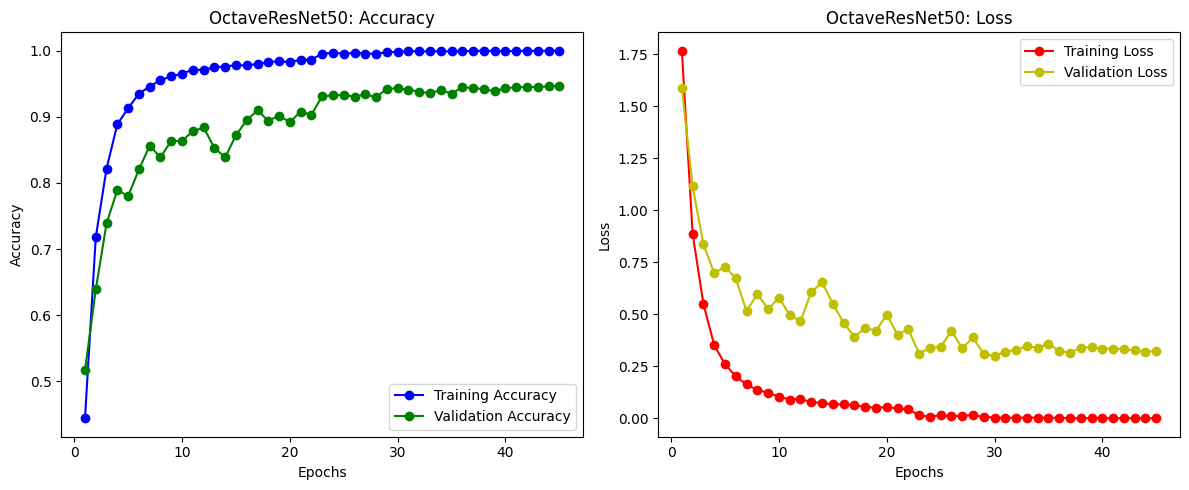

In [18]:
def plot_model_performance(history, model_name):
    """Generates individual plots for a specific model's training history."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'go-', label='Validation Accuracy')
    plt.title(f'{model_name}: Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'ro-', label='Training Loss')
    plt.plot(epochs, val_loss, 'yo-', label='Validation Loss')
    plt.title(f'{model_name}: Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Usage after model.fit():
# history2 = model2.fit(...)
plot_model_performance(history2, "OctaveResNet50")

## 6. MobileNet
### 6.1 Architecture Definition

In [19]:
import warnings

from keras import backend
from keras import layers
from keras.applications import imagenet_utils
from tensorflow.keras import Model
# _obtain_input_shape defined in the imports cell above


BASE_WEIGHT_PATH = (
    "https://storage.googleapis.com/tensorflow/keras-applications/mobilenet/"
)

def MobileNet(
    input_shape=None,
    alpha=1.0,
    depth_multiplier=1,
    dropout=1e-3,
    include_top=True,
    weights=None,
    input_tensor=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    
    if not (weights in {"imagenet", None} or file_utils.exists(weights)):
        raise ValueError(
            "The `weights` argument should be either "
            "`None` (random initialization), 'imagenet' "
            "(pre-training on ImageNet), "
            "or the path to the weights file to be loaded. "
            f"Received weights={weights}"
        )

    if weights == "imagenet" and include_top and classes != 1000:
        raise ValueError(
            "If using `weights='imagenet'` with `include_top=True`, "
            "`classes` should be 1000.  "
            f"Received classes={classes}"
        )

    # Determine proper input shape and default size.
    if input_shape is None:
        default_size = 224
    else:
        if backend.image_data_format() == "channels_first":
            rows = input_shape[1]
            cols = input_shape[2]
        else:
            rows = input_shape[0]
            cols = input_shape[1]

        if rows == cols and rows in [128, 160, 192, 224]:
            default_size = rows
        else:
            default_size = 224

    input_shape = _obtain_input_shape(
        input_shape,
        default_size=default_size,
        min_size=32,
        data_format=backend.image_data_format(),
        require_flatten=include_top,
        weights=weights,
    )

    if backend.image_data_format() == "channels_last":
        row_axis, col_axis = (0, 1)
    else:
        row_axis, col_axis = (1, 2)
    rows = input_shape[row_axis]
    cols = input_shape[col_axis]

    if weights == "imagenet":
        if depth_multiplier != 1:
            raise ValueError(
                "If imagenet weights are being loaded, "
                "depth multiplier must be 1.  "
                f"Received depth_multiplier={depth_multiplier}"
            )

        if alpha not in [0.25, 0.50, 0.75, 1.0]:
            raise ValueError(
                "If imagenet weights are being loaded, "
                "alpha can be one of"
                "`0.25`, `0.50`, `0.75` or `1.0` only.  "
                f"Received alpha={alpha}"
            )

        if rows != cols or rows not in [128, 160, 192, 224]:
            rows = 224
            warnings.warn(
                "`input_shape` is undefined or non-square, "
                "or `rows` is not in [128, 160, 192, 224]. "
                "Weights for input shape (224, 224) will be "
                "loaded as the default.",
                stacklevel=2,
            )

    if input_tensor is None:
        img_input = layers.Input(shape=input_shape)
    else:
        if not backend.is_keras_tensor(input_tensor):
            img_input = layers.Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    x = _conv_block(img_input, 32, alpha, strides=(2, 2))
    x = _depthwise_conv_block(x, 64, alpha, depth_multiplier, block_id=1)

    x = _depthwise_conv_block(
        x, 128, alpha, depth_multiplier, strides=(2, 2), block_id=2
    )
    x = _depthwise_conv_block(x, 128, alpha, depth_multiplier, block_id=3)

    x = _depthwise_conv_block(
        x, 256, alpha, depth_multiplier, strides=(2, 2), block_id=4
    )
    x = _depthwise_conv_block(x, 256, alpha, depth_multiplier, block_id=5)

    x = _depthwise_conv_block(
        x, 512, alpha, depth_multiplier, strides=(2, 2), block_id=6
    )
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=7)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=8)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=9)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=10)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=11)

    x = _depthwise_conv_block(
        x, 1024, alpha, depth_multiplier, strides=(2, 2), block_id=12
    )
    x = _depthwise_conv_block(x, 1024, alpha, depth_multiplier, block_id=13)

    if include_top:
        x = layers.GlobalAveragePooling2D(keepdims=True)(x)
        x = layers.Dropout(dropout, name="dropout")(x)
        x = layers.Conv2D(classes, (1, 1), padding="same", name="conv_preds")(x)
        x = layers.Reshape((classes,), name="reshape_2")(x)
        x = layers.Activation(
            activation=classifier_activation, name="predictions"
        )(x)
    else:
        if pooling == "avg":
            x = layers.GlobalAveragePooling2D()(x)
        elif pooling == "max":
            x = layers.GlobalMaxPooling2D()(x)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = input_tensor
    else:
        inputs = img_input

    # Create model.
    model = Model(inputs, x, name=f"mobilenet_{alpha:0.2f}_{rows}")

    # Load weights.
    if weights == "imagenet":
        if alpha == 1.0:
            alpha_text = "1_0"
        elif alpha == 0.75:
            alpha_text = "7_5"
        elif alpha == 0.50:
            alpha_text = "5_0"
        else:
            alpha_text = "2_5"

        if include_top:
            model_name = "mobilenet_%s_%d_tf.h5" % (alpha_text, rows)
            weight_path = BASE_WEIGHT_PATH + model_name
            weights_path = tf.keras.utils.get_file(
                model_name, weight_path, cache_subdir="models"
            )
        else:
            model_name = "mobilenet_%s_%d_tf_no_top.h5" % (alpha_text, rows)
            weight_path = BASE_WEIGHT_PATH + model_name
            weights_path = tf.keras.utils.get_file(
                model_name, weight_path, cache_subdir="models"
            )
        model.load_weights(weights_path)
    elif weights is not None:
        model.load_weights(weights)

    return model


def _conv_block(inputs, filters, alpha, kernel=(3, 3), strides=(1, 1)):
    
    channel_axis = 1 if backend.image_data_format() == "channels_first" else -1
    filters = int(filters * alpha)
    x = layers.Conv2D(
        filters,
        kernel,
        padding="same",
        use_bias=False,
        strides=strides,
        name="conv1",
    )(inputs)
    x = layers.BatchNormalization(axis=channel_axis, name="conv1_bn")(x)
    return layers.ReLU(6.0, name="conv1_relu")(x)


def _depthwise_conv_block(
    inputs,
    pointwise_conv_filters,
    alpha,
    depth_multiplier=1,
    strides=(1, 1),
    block_id=1,
):
    
    channel_axis = 1 if backend.image_data_format() == "channels_first" else -1
    pointwise_conv_filters = int(pointwise_conv_filters * alpha)

    if strides == (1, 1):
        x = inputs
    else:
        x = layers.ZeroPadding2D(
            ((0, 1), (0, 1)), name="conv_pad_%d" % block_id
        )(inputs)
    x = layers.DepthwiseConv2D(
        (3, 3),
        padding="same" if strides == (1, 1) else "valid",
        depth_multiplier=depth_multiplier,
        strides=strides,
        use_bias=False,
        name="conv_dw_%d" % block_id,
    )(x)
    x = layers.BatchNormalization(
        axis=channel_axis, name="conv_dw_%d_bn" % block_id
    )(x)
    x = layers.ReLU(6.0, name="conv_dw_%d_relu" % block_id)(x)

    x = layers.Conv2D(
        pointwise_conv_filters,
        (1, 1),
        padding="same",
        use_bias=False,
        strides=(1, 1),
        name="conv_pw_%d" % block_id,
    )(x)
    x = layers.BatchNormalization(
        axis=channel_axis, name="conv_pw_%d_bn" % block_id
    )(x)
    return layers.ReLU(6.0, name="conv_pw_%d_relu" % block_id)(x)



def preprocess_input(x, data_format=None):
    return imagenet_utils.preprocess_input(
        x, data_format=data_format, mode="tf"
    )


def decode_predictions(preds, top=5):
    return imagenet_utils.decode_predictions(preds, top=top)

### 6.2 Build & Train MobileNet

In [21]:
# ── Free GPU memory from previous model ─────────────────────────────────────
import gc
tf.keras.backend.clear_session()
gc.collect()

run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="MobileNet",
    config={
        **BASE_CONFIG,
        "model":         "MobileNet",
        "learning_rate": 1e-4,
        "dropout":       1e-3,
    }
)

model3 = MobileNet(input_shape=(64,64,3), classes=num_classes)
model3.compile(
    optimizer=make_optimizer(lr=wandb.config.learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model3.summary()
history3 = model3.fit(
    x_train_bls, y_train_one_hot,
    epochs=100,
    batch_size=wandb.config.batch_size,
    validation_data=(x_test, y_test_one_hot),
    callbacks=make_callbacks('mobilenet'),
    verbose=1
)

loss3, acc3 = model3.evaluate(x_test, y_test_one_hot, verbose=0)
wandb.run.summary["test_accuracy"] = acc3
wandb.run.summary["test_loss"]     = loss3

wandb.finish()

with open('history_mobilenet.pkl', 'wb') as f:
    pickle.dump(history3.history, f)

Model: "mobilenet_1.00_64"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 conv1 (Conv2D)              (None, 32, 32, 32)        864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 32, 32, 32)       128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 32, 32, 32)        0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 32, 32, 32)       288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 32, 32, 32)       128       
 ation)                                          

test_accuracy,0.83482
test_loss,0.8964


In [ ]:
# model3 = MobileNet(input_shape=(64,64,3), classes=num_classes)
# model3.compile(optimizer=make_optimizer(lr=1e-4),
#                loss='categorical_crossentropy',
#             #    metrics=['accuracy'])
# model3.summary()


In [ ]:
# history3 = model3.fit(
#     x_train_bls, y_train_one_hot,
#     epochs=100,
#     batch_size=64,
#     validation_data=(x_test, y_test_one_hot),
#     callbacks=make_callbacks('mobilenet'),
#     verbose=1
# )
# with open('history_mobilenet.pkl', 'wb') as f:
#     pickle.dump(history3.history, f)


In [ ]:
# loss3, acc3 = model3.evaluate(x_test, y_test_one_hot, verbose=0)
# print(f"MobileNet  →  Test Accuracy: {acc3:.4f}  |  Test Loss: {loss3:.4f}")


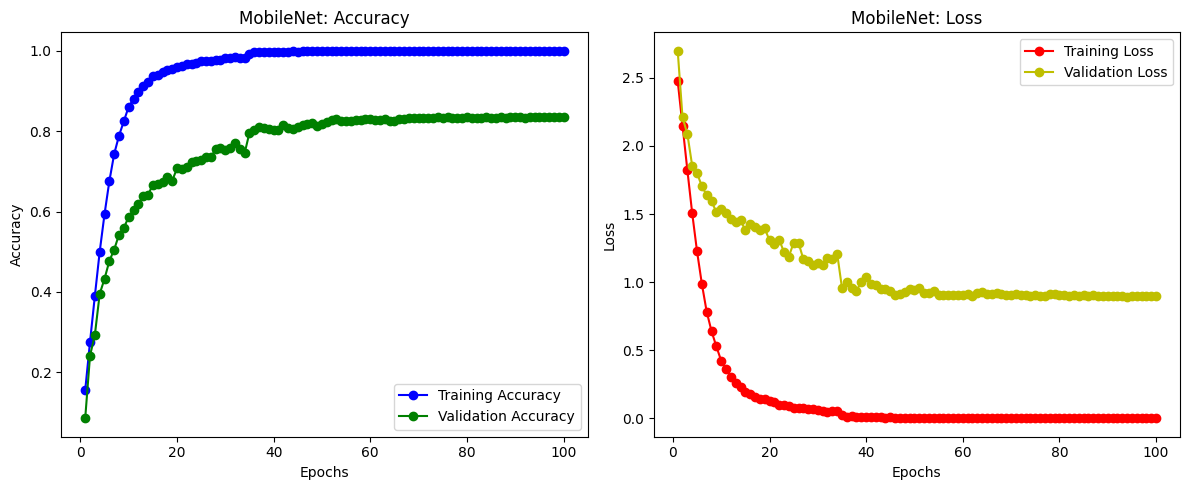

In [25]:
def plot_model_performance(history, model_name):
    """Generates individual plots for a specific model's training history."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'go-', label='Validation Accuracy')
    plt.title(f'{model_name}: Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'ro-', label='Training Loss')
    plt.plot(epochs, val_loss, 'yo-', label='Validation Loss')
    plt.title(f'{model_name}: Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Usage after model.fit():
# history2 = model2.fit(...)
plot_model_performance(history3, "MobileNet")

## 7. DenseNet121
### 7.1 Architecture Definition

In [26]:
from keras import backend
from keras import layers
from keras.applications import imagenet_utils
from tensorflow.keras.models import Model
# _obtain_input_shape defined in the imports cell above

BASE_WEIGHTS_PATH = (
    "https://storage.googleapis.com/tensorflow/keras-applications/densenet/"
)
DENSENET121_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet121_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET121_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5"
)
DENSENET169_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet169_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET169_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet169_weights_tf_dim_ordering_tf_kernels_notop.h5"
)
DENSENET201_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet201_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET201_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet201_weights_tf_dim_ordering_tf_kernels_notop.h5"
)


def dense_block(x, blocks, name):
    
    for i in range(blocks):
        x = conv_block(x, 32, name=name + "_block" + str(i + 1))
    return x


def transition_block(x, reduction, name):
    
    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1
    x = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_bn"
    )(x)
    x = layers.Activation("relu", name=name + "_relu")(x)
    x = layers.Conv2D(
        int(x.shape[bn_axis] * reduction),
        1,
        use_bias=False,
        name=name + "_conv",
    )(x)
    x = layers.AveragePooling2D(2, strides=2, name=name + "_pool")(x)
    return x


def conv_block(x, growth_rate, name):
    
    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1
    x1 = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_0_bn"
    )(x)
    x1 = layers.Activation("relu", name=name + "_0_relu")(x1)
    x1 = layers.Conv2D(
        4 * growth_rate, 1, use_bias=False, name=name + "_1_conv"
    )(x1)
    x1 = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_1_bn"
    )(x1)
    x1 = layers.Activation("relu", name=name + "_1_relu")(x1)
    x1 = layers.Conv2D(
        growth_rate, 3, padding="same", use_bias=False, name=name + "_2_conv"
    )(x1)
    x = layers.Concatenate(axis=bn_axis, name=name + "_concat")([x, x1])
    return x


def DenseNet(
    blocks,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    
    if backend.image_data_format() == "channels_first":
        raise ValueError(
            "DenseNet does not support the channels_first image data "
            "format. Switch to channels_last by editing your local "
            "config file at ~/.keras/keras.json"
        )
    if not (weights in {"imagenet", None} or file_utils.exists(weights)):
        raise ValueError(
            "The weights argument should be either "
            "None (random initialization), imagenet "
            "(pre-training on ImageNet), "
            "or the path to the weights file to be loaded."
        )

    if weights == "imagenet" and include_top and classes != 1000:
        raise ValueError(
            'If using weights as "imagenet" with include_top'
            " as true, classes should be 1000"
        )

    # Determine proper input shape
    input_shape = _obtain_input_shape(
        input_shape,
        default_size=224,
        min_size=32,
        data_format=backend.image_data_format(),
        require_flatten=include_top,
        weights=weights,
    )

    if input_tensor is None:
        img_input = layers.Input(shape=input_shape)
    else:
        if not backend.is_keras_tensor(input_tensor):
            img_input = layers.Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1

    x = layers.ZeroPadding2D(padding=((3, 3), (3, 3)))(img_input)
    x = layers.Conv2D(64, 7, strides=2, use_bias=False, name="conv1m1")(x)
    x = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name="conv"
    )(x)
    x = layers.Activation("relu", name="conv1_relu")(x)
    x = layers.ZeroPadding2D(padding=((1, 1), (1, 1)))(x)
    x = layers.MaxPooling2D(3, strides=2, name="pool1")(x)

    x = dense_block(x, blocks[0], name="conv2m1")
    x = transition_block(x, 0.5, name="pool2")
    x = dense_block(x, blocks[1], name="conv3m1")
    x = transition_block(x, 0.5, name="pool3")
    x = dense_block(x, blocks[2], name="conv4m1")
    x = transition_block(x, 0.5, name="pool4")
    x = dense_block(x, blocks[3], name="conv5m1")

    x = layers.BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name="bn")(x)
    x = layers.Activation("relu", name="relu")(x)

    if include_top:
        x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
        x = layers.Dense(classes, activation=classifier_activation, name="predictions")(x)
    else:
        if pooling == "avg":
            x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
        elif pooling == "max":
            x = layers.GlobalMaxPooling2D(name="max_pool")(x)

    # Ensure that the model takes into account
    # any potential predecessors of input_tensor.
    if input_tensor is not None:
        inputs = operation_utils.get_source_inputs(input_tensor)
    else:
        inputs = img_input

    # Create model.
    if blocks == [6, 12, 24, 16]:
        model = Model(inputs, x, name="densenet121")
    elif blocks == [6, 12, 32, 32]:
        model = Model(inputs, x, name="densenet169")
    elif blocks == [6, 12, 48, 32]:
        model = Model(inputs, x, name="densenet201")
    else:
        model = Model(inputs, x, name="densenet")

    # Load weights.
    if weights == "imagenet":
        if include_top:
            if blocks == [6, 12, 24, 16]:
                weights_path = file_utils.get_file(
                    "densenet121_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET121_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="9d60b8095a5708f2dcce2bca79d332c7",
                )
            elif blocks == [6, 12, 32, 32]:
                weights_path = file_utils.get_file(
                    "densenet169_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET169_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="d699b8f76981ab1b30698df4c175e90b",
                )
            elif blocks == [6, 12, 48, 32]:
                weights_path = file_utils.get_file(
                    "densenet201_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET201_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="1ceb130c1ea1b78c3bf6114dbdfd8807",
                )
        else:
            if blocks == [6, 12, 24, 16]:
                weights_path = file_utils.get_file(
                    "densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET121_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="30ee3e1110167f948a6b9946edeeb738",
                )
            elif blocks == [6, 12, 32, 32]:
                weights_path = file_utils.get_file(
                    "densenet169_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET169_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="b8c4d4c20dd625c148057b9ff1c1176b",
                )
            elif blocks == [6, 12, 48, 32]:
                weights_path = file_utils.get_file(
                    "densenet201_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET201_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="c13680b51ded0fb44dff2d8f86ac8bb1",
                )
        model.load_weights(weights_path)
    elif weights is not None:
        model.load_weights(weights)

    return model




def DenseNet121(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet121 architecture."""
    return DenseNet(
        [6, 12, 24, 16],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )




def DenseNet169(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet169 architecture."""
    return DenseNet(
        [6, 12, 32, 32],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )




def DenseNet201(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet201 architecture."""
    return DenseNet(
        [6, 12, 48, 32],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )


def preprocess_input(x, data_format=None):
    return imagenet_utils.preprocess_input(
        x, data_format=data_format, mode="torch"
    )


def decode_predictions(preds, top=5):
    return imagenet_utils.decode_predictions(preds, top=top)

### 7.2 Build & Train DenseNet121

In [31]:
# ── Aggressively free GPU memory ─────────────────────────────────────────────
import gc

for _var in ['model2', 'model3', 'model4', 'model5']:
    if _var in dir():
        exec(f'del {_var}')

tf.keras.backend.clear_session()
gc.collect()

tf.keras.mixed_precision.set_global_policy('float32')

run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="DenseNet121",
    config={
        **BASE_CONFIG,
        "batch_size":    4,
        "model":         "DenseNet121",
        "learning_rate": 1e-4,
        "dropout":       0.3,
        "blocks":        [6, 12, 24, 16],
    }
)

model4 = DenseNet121(input_shape=(64,64,3), classes=num_classes, weights=None)
model4.compile(
    optimizer=make_optimizer(lr=wandb.config.learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model4.summary()

history4 = model4.fit(
    x_train_bls, y_train_one_hot,
    epochs=100,
    batch_size=wandb.config.batch_size,   # 4
    validation_data=(x_test, y_test_one_hot),
    callbacks=make_callbacks('densenet121'),
    verbose=1
)

# ── Save history immediately after fit – before evaluate can OOM ─────────────
with open('history_densenet121.pkl', 'wb') as f:
    pickle.dump(history4.history, f)
print("History saved to history_densenet121.pkl")

# ── Evaluate on CPU to avoid VRAM exhaustion after training ──────────────────
# GPU is full after fit; copying weights to CPU costs nothing and is reliable.
with tf.device('/CPU:0'):
    loss4, acc4 = model4.evaluate(x_test, y_test_one_hot,
                                  batch_size=32, verbose=1)

print(f"DenseNet121 → Test Accuracy: {acc4:.4f} | Test Loss: {loss4:.4f}")
wandb.run.summary["test_accuracy"] = acc4
wandb.run.summary["test_loss"]     = loss4

wandb.finish()

Model: "densenet121"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 64, 64, 3)]  0           []                               
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 70, 70, 3)   0           ['input_1[0][0]']                
                                                                                                  
 conv1m1 (Conv2D)               (None, 32, 32, 64)   9408        ['zero_padding2d[0][0]']         
                                                                                                  
 conv (BatchNormalization)      (None, 32, 32, 64)   256         ['conv1m1[0][0]']                
                                                                                        

KeyboardInterrupt: 

In [ ]:
# model4 = DenseNet121(input_shape=(64,64,3), classes=num_classes)
# model4.compile(optimizer=make_optimizer(lr=1e-4),
#                loss='categorical_crossentropy',
#                metrics=['accuracy'])
# model4.summary()


In [ ]:
# history4 = model4.fit(
#     x_train_bls, y_train_one_hot,
#     epochs=100,
#     batch_size=64,
#     validation_data=(x_test, y_test_one_hot),
#     callbacks=make_callbacks('densenet121'),
#     verbose=1
# )
# with open('history_densenet121.pkl', 'wb') as f:
#     pickle.dump(history4.history, f)


In [ ]:
# loss4, acc4 = model4.evaluate(x_test, y_test_one_hot, verbose=0)
# print(f"DenseNet121  →  Test Accuracy: {acc4:.4f}  |  Test Loss: {loss4:.4f}")


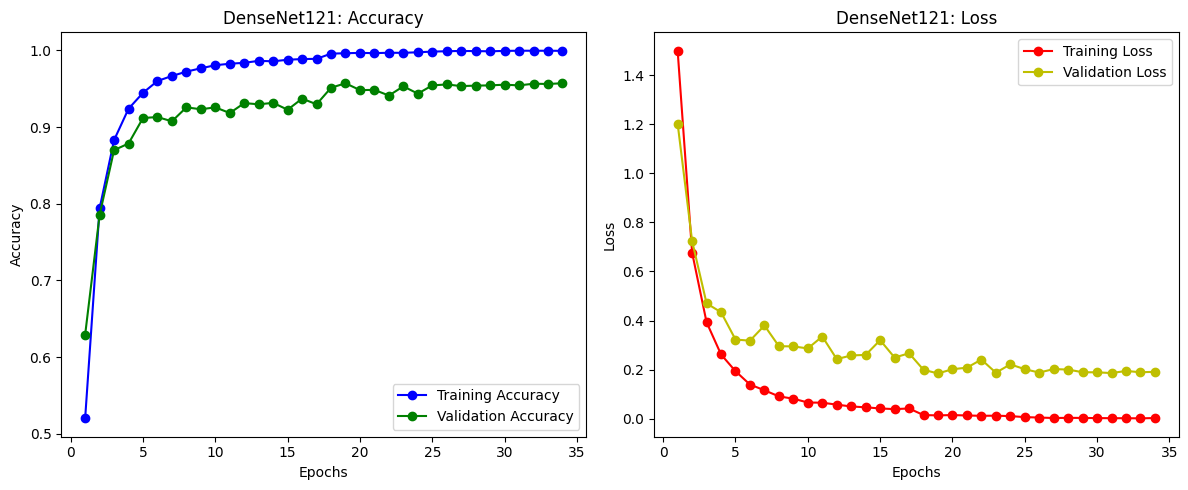

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [32]:
def plot_model_performance(history, model_name):
    """Generates individual plots for a specific model's training history."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'go-', label='Validation Accuracy')
    plt.title(f'{model_name}: Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'ro-', label='Training Loss')
    plt.plot(epochs, val_loss, 'yo-', label='Validation Loss')
    plt.title(f'{model_name}: Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Usage after model.fit():
# history2 = model2.fit(...)
plot_model_performance(history4, "DenseNet121")

## 8. DualPathNetwork (DPN92)
### 8.1 Architecture Definition

In [10]:
import tensorflow.keras.utils as conv_utils
from __future__ import print_function
from __future__ import absolute_import
from __future__ import division
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Reshape,Lambda
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, UpSampling2D
from tensorflow.keras.layers import AveragePooling2D, MaxPooling2D,GlobalAveragePooling2D,GlobalMaxPooling2D
import numpy as np
import warnings
from keras.layers import Input
from tensorflow.keras.layers import concatenate  # For concatenation
from tensorflow.keras.layers import add          # For addition
from tensorflow.keras.layers import BatchNormalization, LayerNormalization
from keras.regularizers import l2
from tensorflow.python.keras.utils.layer_utils import convert_dense_weights_data_format
from tensorflow.keras.utils import get_file
from tensorflow.keras.utils import get_source_inputs
from tensorflow.keras.applications.imagenet_utils import decode_predictions
import keras.backend as K
# _obtain_input_shape defined in the imports cell above

__all__ = ['DualPathNetwork', 'DPN92', 'DPN98', 'DPN137', 'DPN107', 'preprocess_input', 'decode_predictions']


def preprocess_input(x, data_format=None):
    """Preprocesses a tensor encoding a batch of images.
       Obtained from https://github.com/cypw/DPNs

        # Arguments
            x: input Numpy tensor, 4D.
            data_format: data format of the image tensor.

        # Returns
            Preprocessed tensor.
        """
    if data_format is None:
        data_format = K.image_data_format()
    assert data_format in {'channels_last', 'channels_first'}

    if data_format == 'channels_first':
        # 'RGB'->'BGR'
        x = x[:, ::-1, :, :]
        # Zero-center by mean pixel
        x[:, 0, :, :] -= 104
        x[:, 1, :, :] -= 117
        x[:, 2, :, :] -= 128
    else:
        # 'RGB'->'BGR'
        x = x[:, :, :, ::-1]
        # Zero-center by mean pixel
        x[:, :, :, 0] -= 104
        x[:, :, :, 1] -= 117
        x[:, :, :, 2] -= 124

    x *= 0.0167
    return x


def DualPathNetwork(input_shape=None,
                    initial_conv_filters=64,
                    depth=[3, 4, 20, 3],
                    filter_increment=[16, 32, 24, 128],
                    cardinality=32,
                    width=3,
                    weight_decay=0,
                    include_top=True,
                    weights=None,
                    input_tensor=None,
                    pooling=None,
                    classes=1000):
    

    if weights not in {'imagenet', None}:
        raise ValueError('The `weights` argument should be either '
                         '`None` (random initialization) or `imagenet` '
                         '(pre-training on ImageNet).')

    if weights == 'imagenet' and include_top and classes != 1000:
        raise ValueError('If using `weights` as imagenet with `include_top`'
                         ' as true, `classes` should be 1000')

    assert len(depth) == len(filter_increment), "The length of filter increment list must match the length " \
                                                "of the depth list."

    # Determine proper input shape
    input_shape = _obtain_input_shape(input_shape,
                                      default_size=224,
                                      min_size=32,
                                      data_format=K.image_data_format(),
                                      require_flatten=include_top)

    if input_tensor is None:
        img_input = Input(shape=input_shape)
    else:
        if not K.is_keras_tensor(input_tensor):
            img_input = Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    x = _create_dpn(classes, img_input, include_top, initial_conv_filters,
                    filter_increment, depth, cardinality, width, weight_decay, pooling)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = get_source_inputs(input_tensor)
    else:
        inputs = img_input
    # Create model.
    model = Model(inputs, x, name='resnext')

    # load weights

    return model


def DPN92(input_shape=None,
          include_top=True,
          weights=None,
          input_tensor=None,
          pooling=None,
          classes=1000):
    return DualPathNetwork(input_shape, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN98(input_shape=None,
          include_top=True,
          weights=None,
          input_tensor=None,
          pooling=None,
          classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=96, depth=[3, 6, 20, 3], filter_increment=[16, 32, 32, 128],
                           cardinality=40, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN137(input_shape=None,
           include_top=True,
           weights=None,
           input_tensor=None,
           pooling=None,
           classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=128, depth=[4, 8, 28, 3], filter_increment=[16, 32, 32, 128],
                           cardinality=40, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN107(input_shape=None,
           include_top=True,
           weights=None,
           input_tensor=None,
           pooling=None,
           classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=128, depth=[4, 8, 20, 3], filter_increment=[20, 64, 64, 128],
                           cardinality=50, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def _initial_conv_block_inception(input, initial_conv_filters, weight_decay=5e-4):
    ''' Adds an initial conv block, with batch norm and relu for the DPN
    Args:
        input: input tensor
        initial_conv_filters: number of filters for initial conv block
        weight_decay: weight decay factor
    Returns: a keras tensor
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = Conv2D(initial_conv_filters, (7, 7), padding='same', use_bias=False, kernel_initializer='he_normal',
               kernel_regularizer=l2(weight_decay), strides=(2, 2))(input)
    x = BatchNormalization(axis=channel_axis)(x)
    x = Activation('relu')(x)

    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    return x


def _bn_relu_conv_block(input, filters, kernel=(3, 3), stride=(1, 1), weight_decay=5e-4):
    ''' Adds a Batchnorm-Relu-Conv block for DPN
    Args:
        input: input tensor
        filters: number of output filters
        kernel: convolution kernel size
        stride: stride of convolution
    Returns: a keras tensor
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = Conv2D(filters, kernel, padding='same', use_bias=False, kernel_initializer='he_normal',
               kernel_regularizer=l2(weight_decay), strides=stride)(input)
    x = BatchNormalization(axis=channel_axis)(x)
    x = Activation('relu')(x)
    return x


def _grouped_convolution_block(input, grouped_channels, cardinality, strides, weight_decay=5e-4):
    ''' Adds a grouped convolution block. It is an equivalent block from the paper
    Args:
        input: input tensor
        grouped_channels: grouped number of filters
        cardinality: cardinality factor describing the number of groups
        strides: performs strided convolution for downscaling if > 1
        weight_decay: weight decay term
    Returns: a keras tensor
    '''
    init = input
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    group_list = []

    if cardinality == 1:
        # with cardinality 1, it is a standard convolution
        x = Conv2D(grouped_channels, (3, 3), padding='same', use_bias=False, strides=strides,
                   kernel_initializer='he_normal', kernel_regularizer=l2(weight_decay))(init)
        x = BatchNormalization(axis=channel_axis)(x)
        x = Activation('relu')(x)
        return x

    for c in range(cardinality):
        x = Lambda(lambda z: z[:, :, :, c * grouped_channels:(c + 1) * grouped_channels]
                   if K.image_data_format() == 'channels_last' else
                   lambda z: z[:, c * grouped_channels:(c + 1) * grouped_channels, :, :])(input)

        x = Conv2D(grouped_channels, (3, 3), padding='same', use_bias=False, strides=strides,
                   kernel_initializer='he_normal', kernel_regularizer=l2(weight_decay))(x)

        group_list.append(x)

    group_merge = concatenate(group_list, axis=channel_axis)
    group_merge = BatchNormalization(axis=channel_axis)(group_merge)
    group_merge = Activation('relu')(group_merge)
    return group_merge


def _dual_path_block(input, pointwise_filters_a, grouped_conv_filters_b, pointwise_filters_c,
                     filter_increment, cardinality, block_type='normal'):
    '''
    Creates a Dual Path Block. The first path is a ResNeXt type
    grouped convolution block. The second is a DenseNet type dense
    convolution block.

    Args:
        input: input tensor
        pointwise_filters_a: number of filters for the bottleneck
            pointwise convolution
        grouped_conv_filters_b: number of filters for the grouped
            convolution block
        pointwise_filters_c: number of filters for the bottleneck
            convolution block
        filter_increment: number of filters that will be added
        cardinality: cardinality factor
        block_type: determines what action the block will perform
            - `projection`: adds a projection connection
            - `downsample`: downsamples the spatial resolution
            - `normal`    : simple adds a dual path connection

    Returns: a list of two output tensors - one path of ResNeXt
        and another path for DenseNet

    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1
    grouped_channels = int(grouped_conv_filters_b / cardinality)

    init = concatenate(input, axis=channel_axis) if isinstance(input, list) else input

    if block_type == 'projection':
        stride = (1, 1)
        projection = True
    elif block_type == 'downsample':
        stride = (2, 2)
        projection = True
    elif block_type == 'normal':
        stride = (1, 1)
        projection = False
    else:
        raise ValueError('`block_type` must be one of ["projection", "downsample", "normal"]. Given %s' % block_type)

    if projection:
        projection_path = _bn_relu_conv_block(init, filters=pointwise_filters_c + 2 * filter_increment,
                                              kernel=(1, 1), stride=stride)
        input_residual_path = Lambda(lambda z: z[:, :, :, :pointwise_filters_c]
                                     if K.image_data_format() == 'channels_last' else
                                     z[:, :pointwise_filters_c, :, :])(projection_path)
        input_dense_path = Lambda(lambda z: z[:, :, :, pointwise_filters_c:]
                                  if K.image_data_format() == 'channels_last' else
                                  z[:, pointwise_filters_c:, :, :])(projection_path)
    else:
        input_residual_path = input[0]
        input_dense_path = input[1]

    x = _bn_relu_conv_block(init, filters=pointwise_filters_a, kernel=(1, 1))
    x = _grouped_convolution_block(x, grouped_channels=grouped_channels, cardinality=cardinality, strides=stride)
    x = _bn_relu_conv_block(x, filters=pointwise_filters_c + filter_increment, kernel=(1, 1))

    output_residual_path = Lambda(lambda z: z[:, :, :, :pointwise_filters_c]
                                  if K.image_data_format() == 'channels_last' else
                                  z[:, :pointwise_filters_c, :, :])(x)
    output_dense_path = Lambda(lambda z: z[:, :, :, pointwise_filters_c:]
                               if K.image_data_format() == 'channels_last' else
                               z[:, pointwise_filters_c:, :, :])(x)

    residual_path = add([input_residual_path, output_residual_path])
    dense_path = concatenate([input_dense_path, output_dense_path], axis=channel_axis)

    return [residual_path, dense_path]


def _create_dpn(nb_classes, img_input, include_top, initial_conv_filters,
                filter_increment, depth, cardinality=32, width=3, weight_decay=5e-4, pooling=None):
    ''' Creates a ResNeXt model with specified parameters
    Args:
        initial_conv_filters: number of features for the initial convolution
        include_top: Flag to include the last dense layer
        initial_conv_filters: number of features for the initial convolution
        filter_increment: number of filters incremented per block, defined as a list.
            DPN-92  = [16, 32, 24, 128]
            DON-98  = [16, 32, 32, 128]
            DPN-131 = [16, 32, 32, 128]
            DPN-107 = [20, 64, 64, 128]
        depth: number or layers in the each block, defined as a list.
            DPN-92  = [3, 4, 20, 3]
            DPN-98  = [3, 6, 20, 3]
            DPN-131 = [4, 8, 28, 3]
            DPN-107 = [4, 8, 20, 3]
        width: width multiplier for network
        weight_decay: weight_decay (l2 norm)
        pooling: Optional pooling mode for feature extraction
            when `include_top` is `False`.
            - `None` means that the output of the model will be
                the 4D tensor output of the
                last convolutional layer.
            - `avg` means that global average pooling
                will be applied to the output of the
                last convolutional layer, and thus
                the output of the model will be a 2D tensor.
            - `max` means that global max pooling will
                be applied.
            - `max-avg` means that both global average and global max
                pooling will be applied to the output of the last
                convolution layer
    Returns: a Keras Model
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1
    N = list(depth)
    base_filters = 256

    # block 1 (initial conv block)
    x = _initial_conv_block_inception(img_input, initial_conv_filters, weight_decay)

    # block 2 (projection block)
    filter_inc = filter_increment[0]
    filters = int(cardinality * width)

    x = _dual_path_block(x, pointwise_filters_a=filters,
                         grouped_conv_filters_b=filters,
                         pointwise_filters_c=base_filters,
                         filter_increment=filter_inc,
                         cardinality=cardinality,
                         block_type='projection')

    for i in range(N[0] - 1):
        x = _dual_path_block(x, pointwise_filters_a=filters,
                             grouped_conv_filters_b=filters,
                             pointwise_filters_c=base_filters,
                             filter_increment=filter_inc,
                             cardinality=cardinality,
                             block_type='normal')

    # remaining blocks
    for k in range(1, len(N)):
        print("BLOCK %d" % (k + 1))
        filter_inc = filter_increment[k]
        filters *= 2
        base_filters *= 2

        x = _dual_path_block(x, pointwise_filters_a=filters,
                             grouped_conv_filters_b=filters,
                             pointwise_filters_c=base_filters,
                             filter_increment=filter_inc,
                             cardinality=cardinality,
                             block_type='downsample')

        for i in range(N[k] - 1):
            x = _dual_path_block(x, pointwise_filters_a=filters,
                                 grouped_conv_filters_b=filters,
                                 pointwise_filters_c=base_filters,
                                 filter_increment=filter_inc,
                                 cardinality=cardinality,
                                 block_type='normal')

    x = concatenate(x, axis=channel_axis)

    if include_top:
        avg = GlobalAveragePooling2D()(x)
        max = GlobalMaxPooling2D()(x)
        x = add([avg, max])
        x = Lambda(lambda z: 0.5 * z)(x)
        x = Dense(nb_classes, use_bias=False, kernel_regularizer=l2(weight_decay),
                  kernel_initializer='he_normal', activation='softmax')(x)
    else:
        if pooling == 'avg':
            x = GlobalAveragePooling2D()(x)
        elif pooling == 'max':
            x = GlobalMaxPooling2D()(x)
        elif pooling == 'max-avg':
            a = GlobalMaxPooling2D()(x)
            b = GlobalAveragePooling2D()(x)
            x = add([a, b])
            x = Lambda(lambda z: 0.5 * z)(x)

    return x

if __name__ == '__main__':
    model = DPN92((224, 224, 3))

BLOCK 2
BLOCK 3
BLOCK 4


### 8.2 Build & Train DPN92

In [ ]:
# ── Free GPU memory from previous model ──────────────────────────────────────
# !! IMPORTANT: If you hit OOM or 'Dst tensor is not initialized' on a prior
#    run, do Kernel → Restart (without re-running all), then run cells from
#    top to bottom once. The 3500 MB cap in the GPU setup cell only takes
#    effect on a fresh kernel before any TF operation.
import gc

# Delete ALL model and history references so TF's BFC pool can reclaim them
for _var in ['model', 'model2', 'model3', 'model4', 'model5',
             'history', 'history2', 'history3', 'history4', 'history5']:
    if _var in globals():
        del globals()[_var]

tf.keras.backend.clear_session()
gc.collect()

# Enable mixed precision to halve activation memory
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="DPN92",
    config={
        **BASE_CONFIG,
        "model":         "DPN92-lite",
        "batch_size":    4,
        "learning_rate": 5e-5,
        "dropout":       0.3,
        "cardinality":   32,
        # Reduced from original [3,4,20,3] → saves ~40% peak activation memory
        # while keeping the 4-stage DPN92 architecture.
        "depth":         [3, 4, 6, 3],
    }
)

# DPN92() wrapper doesn't expose depth; call DualPathNetwork directly.
model5 = DualPathNetwork(
    input_shape=(64, 64, 3),
    depth=wandb.config.depth,
    cardinality=wandb.config.cardinality,
    classes=num_classes,
)
model5.compile(
    optimizer=make_optimizer(lr=wandb.config.learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model5.summary()
history5 = model5.fit(
    x_train_bls, y_train_one_hot,
    epochs=100,
    batch_size=wandb.config.batch_size,
    validation_data=(x_test, y_test_one_hot),
    callbacks=make_callbacks('dpn92', patience=20, lr_patience=7),
    verbose=1
)

loss5, acc5 = model5.evaluate(x_test, y_test_one_hot, verbose=0)
wandb.run.summary["test_accuracy"] = acc5
wandb.run.summary["test_loss"]     = loss5

wandb.finish()

# Restore default policy for subsequent models
mixed_precision.set_global_policy('float32')

with open('history_dpn92.pkl', 'wb') as f:
    pickle.dump(history5.history, f)


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce GTX 1650, compute capability 7.5


BLOCK 2
BLOCK 3
BLOCK 4
Model: "resnext"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 64, 64, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 32, 32, 64)   9408        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 32, 32, 64)  256         ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 32, 32, 64)   0           ['b

In [ ]:
# model5 = DPN92(input_shape=(64,64,3), classes=num_classes)
# model5.compile(optimizer=make_optimizer(lr=5e-5),   # slightly lower LR: DPN is prone to spikes
#                loss='categorical_crossentropy',
#                metrics=['accuracy'])
# model5.summary()


In [ ]:
# history5 = model5.fit(
#     x_train_bls, y_train_one_hot,
#     epochs=100,
#     batch_size=64,
#     validation_data=(x_test, y_test_one_hot),
#     callbacks=make_callbacks('dpn92', patience=20, lr_patience=7),
#     verbose=1
# )
# with open('history_dpn92.pkl', 'wb') as f:
#     pickle.dump(history5.history, f)


In [ ]:
# loss5, acc5 = model5.evaluate(x_test, y_test_one_hot, verbose=0)
# print(f"DPN92  →  Test Accuracy: {acc5:.4f}  |  Test Loss: {loss5:.4f}")


In [ ]:
def plot_model_performance(history, model_name):
    """Generates individual plots for a specific model's training history."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'go-', label='Validation Accuracy')
    plt.title(f'{model_name}: Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'ro-', label='Training Loss')
    plt.plot(epochs, val_loss, 'yo-', label='Validation Loss')
    plt.title(f'{model_name}: Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Usage after model.fit():
# history2 = model2.fit(...)
plot_model_performance(history5, "Dual-Path Network (DPN92)")

## 9. Training Curves (All Models)

In [ ]:
def plot_training_history(histories, names):
    """Plot accuracy and loss curves for multiple models side-by-side."""
    fig, axes = plt.subplots(2, len(histories), figsize=(6*len(histories), 10))
    for i, (hist, name) in enumerate(zip(histories, names)):
        # Accuracy
        axes[0,i].plot(hist['accuracy'],     label='Train Acc')
        axes[0,i].plot(hist['val_accuracy'], label='Val Acc')
        axes[0,i].set_title(f'{name} — Accuracy')
        axes[0,i].set_xlabel('Epoch')
        axes[0,i].set_ylabel('Accuracy')
        axes[0,i].legend()
        axes[0,i].grid(True)
        # Loss (log scale to handle potential spikes gracefully)
        axes[1,i].plot(hist['loss'],     label='Train Loss')
        axes[1,i].plot(hist['val_loss'], label='Val Loss')
        axes[1,i].set_title(f'{name} — Loss')
        axes[1,i].set_xlabel('Epoch')
        axes[1,i].set_ylabel('Loss (log scale)')
        axes[1,i].set_yscale('log')       # log scale absorbs any remaining spikes
        axes[1,i].legend()
        axes[1,i].grid(True)
    plt.tight_layout()
    plt.show()

all_histories = [history2.history, history3.history, history4.history, history5.history]
all_names     = ['OctaveResNet50', 'MobileNet', 'DenseNet121', 'DPN92']
plot_training_history(all_histories, all_names)


## 10. Ensemble — Meta-Learner (Stacking)
### 10.1 Generate Base-Model Predictions
> **FIX:** meta-learner is trained on `x_meta_val` predictions (not `x_test`).  
> Final accuracy is reported on `x_test` only.

In [ ]:
print("Generating meta-val predictions (for training meta-learner)...")
oct_meta    = model2.predict(x_meta_val, verbose=0)
mob_meta    = model3.predict(x_meta_val, verbose=0)
dense_meta  = model4.predict(x_meta_val, verbose=0)
dpn_meta    = model5.predict(x_meta_val, verbose=0)

print("Generating test predictions (for final evaluation)...")
oct_test    = model2.predict(x_test, verbose=0)
mob_test    = model3.predict(x_test, verbose=0)
dense_test  = model4.predict(x_test, verbose=0)
dpn_test    = model5.predict(x_test, verbose=0)

print("Done.")


### 10.2 Evaluation Helper

In [ ]:
def evaluate_ensemble(name, meta_feats_train, meta_feats_test, y_meta, y_true):
    """
    Train meta-learner on meta_feats_train/y_meta,
    evaluate on meta_feats_test/y_true.
    Returns the trained learner.
    """
    print(f"\n{'='*60}")
    print(f"  Ensemble: {name}")
    print(f"{'='*60}")

    ml = LogisticRegression(max_iter=1000, random_state=42)
    ml.fit(meta_feats_train, y_meta)           # FIX: trained on VAL set, not test set
    preds = ml.predict(meta_feats_test)

    acc  = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_true, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_true, preds, average='weighted', zero_division=0)

    # ROC-AUC using predicted class one-hot (since LR.predict gives hard labels)
    n_cls = int(np.max(y_true)) + 1
    pred_oh = np.eye(n_cls)[preds]
    roc = roc_auc_score(y_true, pred_oh, multi_class='ovr')

    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print()
    print(classification_report(y_true, preds))

    # Confusion matrix
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(8,6))
    plt.matshow(cm, fignum=False, cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # Per-class ROC curves
    plt.figure(figsize=(10,6))
    for i in range(n_cls):
        fpr, tpr, _ = roc_curve(y_true == i, pred_oh[:,i])
        plt.plot(fpr, tpr, label=f'Class {i} (AUC={auc(fpr,tpr):.2f})')
    plt.plot([0,1],[0,1],'--', color='navy')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title(f'OvR ROC — {name}')
    plt.legend(loc='lower right', fontsize=7)
    plt.grid(True)
    plt.show()

    return ml, acc


### 10.3 All Ensemble Combinations

In [ ]:
combos = {
    'Mobile+Oct+DPN':         ([mob_meta, oct_meta,   dpn_meta],
                                [mob_test, oct_test,   dpn_test]),
    'Dense+Oct+DPN':          ([dense_meta, oct_meta,  dpn_meta],
                                [dense_test, oct_test,  dpn_test]),
    'Mobile+Dense+DPN':       ([mob_meta, dense_meta,  dpn_meta],
                                [mob_test, dense_test,  dpn_test]),
    'Mobile+Dense+Oct+DPN':   ([mob_meta, dense_meta, oct_meta, dpn_meta],
                                [mob_test, dense_test, oct_test, dpn_test]),
    'Oct+DPN':                ([oct_meta,  dpn_meta],
                                [oct_test,  dpn_test]),
    'Dense+DPN':              ([dense_meta, dpn_meta],
                                [dense_test, dpn_test]),
    'Mobile+DPN':             ([mob_meta,   dpn_meta],
                                [mob_test,   dpn_test]),
}

results = {}
for name, (train_parts, test_parts) in combos.items():
    meta_train = np.concatenate(train_parts, axis=1)
    meta_test  = np.concatenate(test_parts,  axis=1)
    ml, acc = evaluate_ensemble(name, meta_train, meta_test, y_meta_val, y_test)
    results[name] = acc


In [ ]:
run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="Ensemble-Results",
    config={**BASE_CONFIG, "meta_learner": "LogisticRegression"}
)

# ... your existing ensemble evaluation code runs here ...

# After results dict is populated, log all ensemble accuracies at once
wandb.log({"ensemble_results": wandb.Table(
    columns=["combination", "accuracy"],
    data=[[name, acc] for name, acc in results.items()]
)})

# Log the best combo as a summary metric
best_combo = max(results, key=results.get)
wandb.run.summary["best_ensemble"]          = best_combo
wandb.run.summary["best_ensemble_accuracy"] = results[best_combo]

wandb.finish()

### 10.4 Ensemble Accuracy Comparison

In [ ]:
plt.figure(figsize=(12, 5))
names_sorted = sorted(results, key=results.get, reverse=True)
accs_sorted  = [results[n] for n in names_sorted]
bars = plt.bar(names_sorted, accs_sorted, color='steelblue', edgecolor='black')
plt.ylim(0.8, 1.0)
plt.ylabel('Test Accuracy')
plt.title('Ensemble Accuracy Comparison (Meta-Learner on Val Set — No Leakage)')
plt.xticks(rotation=25, ha='right')
for bar, acc in zip(bars, accs_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\nFinal Rankings:")
for i, (n, a) in enumerate(zip(names_sorted, accs_sorted), 1):
    print(f"  {i}. {n:<30s}  {a:.4f}")


In [ ]:
from sklearn.metrics import classification_report

def show_detailed_metrics(model, x_test, y_test, model_name):
    preds = model.predict(x_test)
    y_pred_classes = np.argmax(preds, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    
    print(f"\n--- Detailed Metrics for {model_name} ---")
    print(classification_report(y_true_classes, y_pred_classes))

# Usage:
show_detailed_metrics(model2, x_test, y_test_one_hot, "OctaveResNet50")